# ipynb/kl1.ipynb - KL 散度分析 / KL divergence analysis

## 项目背景 / Background
KL 散度分析
KL divergence analysis

## 功能模块 / Modules
- KL 散度 / 注意力分布比较
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: collect_*.py、utils/fewshot_analysis_*.py
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



Generating comprehensive KL divergence visualization...


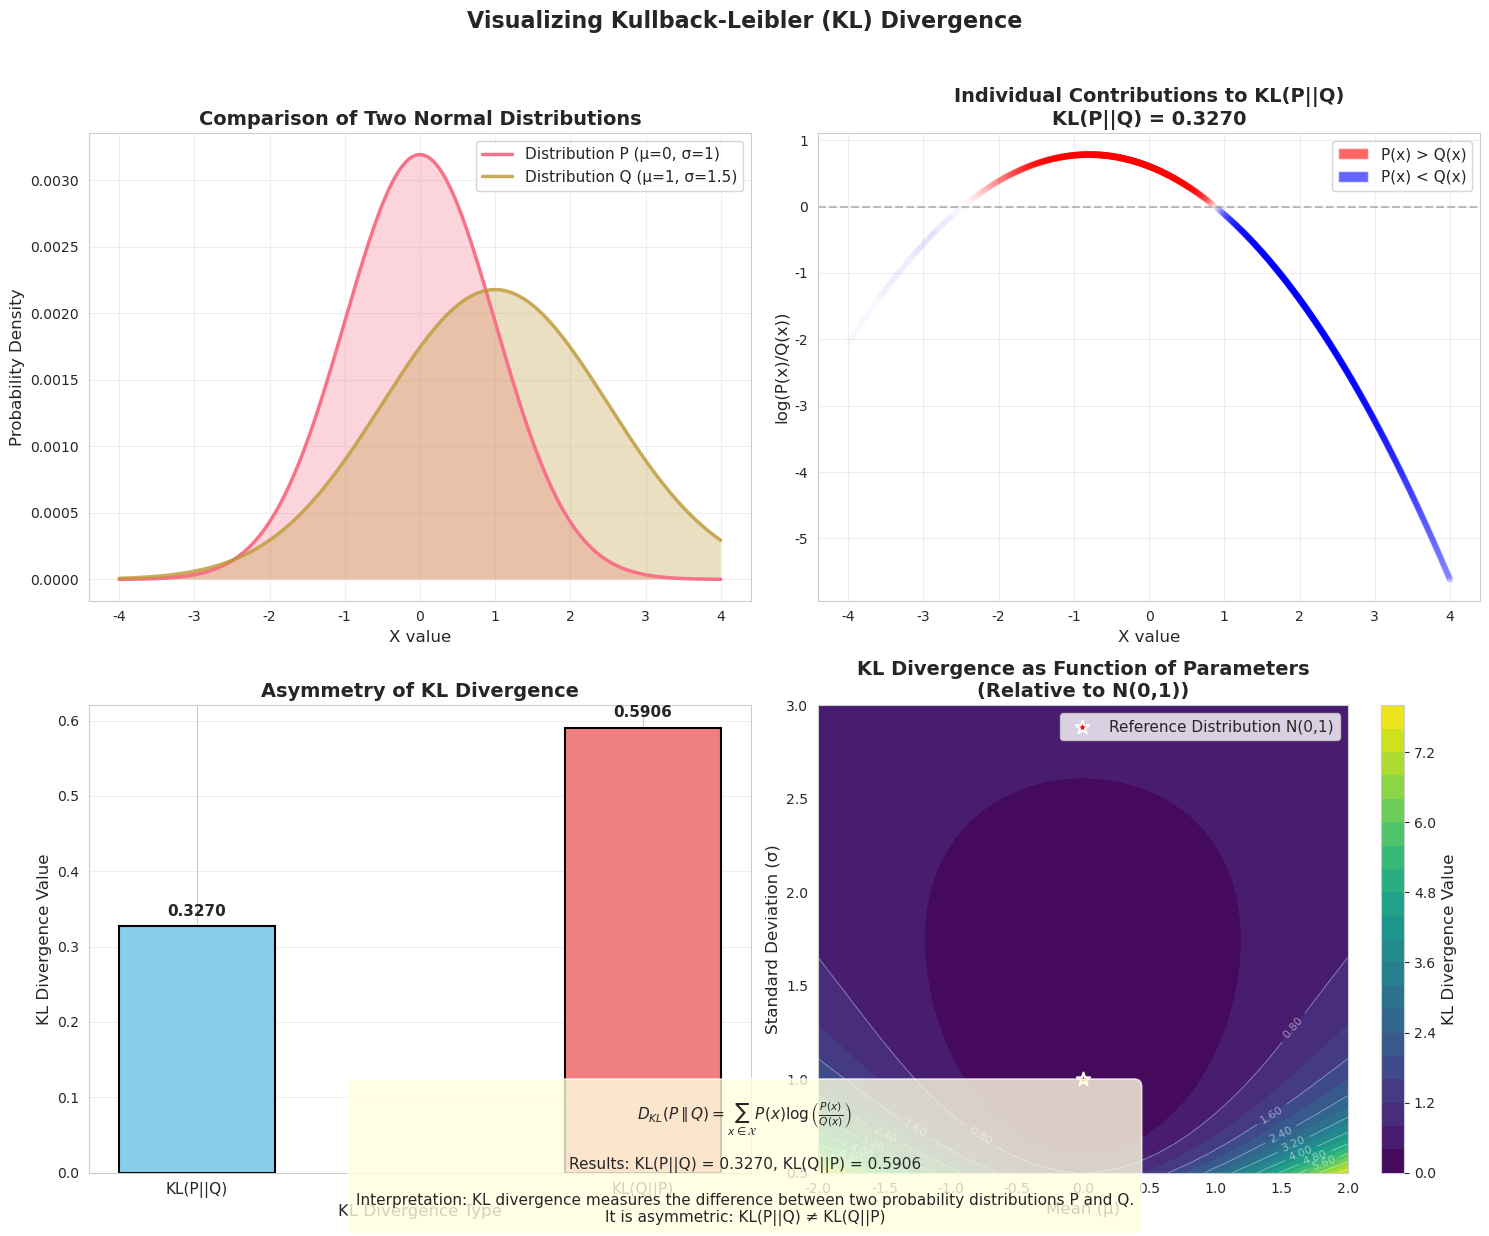


Results Summary:
KL(P||Q) = 0.326964
KL(Q||P) = 0.590600
Difference: 0.263635
Relative difference: 80.63%


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

# Set global parameters for better visuals
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")
sns.set_palette("husl")

def kl_divergence(p, q):
    """Compute KL divergence between two discrete distributions"""
    # Add small epsilon to avoid division by zero or log(0)
    epsilon = 1e-10
    p_safe = p + epsilon
    q_safe = q + epsilon
    p_safe = p_safe / np.sum(p_safe)
    q_safe = q_safe / np.sum(q_safe)
    return np.sum(p_safe * np.log(p_safe / q_safe))

def create_kl_divergence_plot():
    # Create data
    np.random.seed(42)
    x = np.linspace(-4, 4, 1000)
    
    # Define two normal distributions
    # Distribution P: standard normal
    p_mean, p_std = 0, 1
    p_dist = stats.norm(p_mean, p_std)
    p_pdf = p_dist.pdf(x)
    
    # Distribution Q: normal with different parameters
    q_mean, q_std = 1, 1.5
    q_dist = stats.norm(q_mean, q_std)
    q_pdf = q_dist.pdf(x)
    
    # Normalize to create valid probability distributions
    p_pdf = p_pdf / np.sum(p_pdf)
    q_pdf = q_pdf / np.sum(q_pdf)
    
    # Calculate KL divergence
    kl_pq = kl_divergence(p_pdf, q_pdf)
    kl_qp = kl_divergence(q_pdf, p_pdf)
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Plot the two distributions
    ax1 = axes[0, 0]
    ax1.plot(x, p_pdf, label='Distribution P (μ=0, σ=1)', linewidth=2.5)
    ax1.plot(x, q_pdf, label='Distribution Q (μ=1, σ=1.5)', linewidth=2.5, alpha=0.8)
    ax1.fill_between(x, p_pdf, alpha=0.3)
    ax1.fill_between(x, q_pdf, alpha=0.3)
    ax1.set_xlabel('X value', fontsize=12)
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.set_title('Comparison of Two Normal Distributions', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11, loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. Plot the contributions to KL divergence
    ax2 = axes[0, 1]
    
    # Calculate log ratio
    log_ratio = np.log((p_pdf + 1e-10) / (q_pdf + 1e-10))
    
    # Create color mapping based on P(x) vs Q(x)
    colors = np.where(p_pdf > q_pdf, 'red', 'blue')
    alpha_values = np.abs(p_pdf - q_pdf) / np.max(np.abs(p_pdf - q_pdf))
    
    ax2.scatter(x, log_ratio, c=colors, alpha=alpha_values*0.6, s=15)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('X value', fontsize=12)
    ax2.set_ylabel('log(P(x)/Q(x))', fontsize=12)
    ax2.set_title('Individual Contributions to KL(P||Q)\n' + 
                  f'KL(P||Q) = {kl_pq:.4f}', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.6, label='P(x) > Q(x)'),
        Patch(facecolor='blue', alpha=0.6, label='P(x) < Q(x)')
    ]
    ax2.legend(handles=legend_elements, fontsize=11, loc='upper right')
    
    # 3. Demonstrate asymmetry of KL divergence
    ax3 = axes[1, 0]
    
    # Create bar chart for asymmetry demonstration
    bar_width = 0.35
    x_pos = np.arange(2)
    kl_values = [kl_pq, kl_qp]
    labels = ['KL(P||Q)', 'KL(Q||P)']
    
    bars = ax3.bar(x_pos, kl_values, bar_width, 
                   color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)
    
    ax3.set_xlabel('KL Divergence Type', fontsize=12)
    ax3.set_ylabel('KL Divergence Value', fontsize=12)
    ax3.set_title('Asymmetry of KL Divergence', fontsize=14, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(labels, fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, kl_values)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 4. Contour plot showing KL divergence as function of parameters
    ax4 = axes[1, 1]
    
    # Create parameter grid
    mu_range = np.linspace(-2, 2, 50)
    sigma_range = np.linspace(0.5, 3, 50)
    mu_grid, sigma_grid = np.meshgrid(mu_range, sigma_range)
    
    # Calculate KL divergence for each parameter combination
    kl_values_grid = np.zeros_like(mu_grid)
    
    # Reference distribution: standard normal
    ref_dist = stats.norm(0, 1)
    ref_pdf = ref_dist.pdf(x)
    ref_pdf = ref_pdf / np.sum(ref_pdf)
    
    for i in range(len(sigma_range)):
        for j in range(len(mu_range)):
            # Create current distribution
            current_dist = stats.norm(mu_grid[i, j], sigma_grid[i, j])
            current_pdf = current_dist.pdf(x)
            current_pdf = current_pdf / np.sum(current_pdf)
            
            # Calculate KL divergence
            kl_values_grid[i, j] = kl_divergence(ref_pdf, current_pdf)
    
    # Create contour plot
    contour = ax4.contourf(mu_grid, sigma_grid, kl_values_grid, 
                          levels=20, cmap='viridis')
    ax4.set_xlabel('Mean (μ)', fontsize=12)
    ax4.set_ylabel('Standard Deviation (σ)', fontsize=12)
    ax4.set_title('KL Divergence as Function of Parameters\n(Relative to N(0,1))', 
                  fontsize=14, fontweight='bold')
    
    # Add contour lines
    contour_lines = ax4.contour(mu_grid, sigma_grid, kl_values_grid, 
                               levels=10, colors='white', alpha=0.5, linewidths=0.5)
    ax4.clabel(contour_lines, inline=True, fontsize=8, fmt='%.2f')
    
    # Mark the reference distribution point
    ax4.scatter(0, 1, color='red', s=100, marker='*', 
                edgecolors='white', linewidth=1.5, label='Reference Distribution N(0,1)')
    ax4.legend(fontsize=11, loc='upper right')
    
    # Add colorbar
    cbar = plt.colorbar(contour, ax=ax4)
    cbar.set_label('KL Divergence Value', fontsize=12)
    
    # Add main title
    plt.suptitle('Visualizing Kullback-Leibler (KL) Divergence', 
                fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    # Add explanation text at the bottom
    formula_text = (
        r"$D_{KL}(P \parallel Q) = \sum_{x \in \mathcal{X}} P(x) \log\left(\frac{P(x)}{Q(x)}\right)$"
        f"\n\nResults: KL(P||Q) = {kl_pq:.4f}, KL(Q||P) = {kl_qp:.4f}"
        "\n\nInterpretation: KL divergence measures the difference between two probability distributions P and Q."
        "\nIt is asymmetric: KL(P||Q) ≠ KL(Q||P)"
    )
    
    plt.figtext(0.5, 0.01, formula_text, ha='center', fontsize=11, 
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))
    
    plt.show()
    
    return kl_pq, kl_qp

# Alternative: Simplified version for quick understanding
def create_simple_kl_plot():
    """Create a simpler version focusing on core concepts"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    np.random.seed(42)
    x = np.linspace(-3, 3, 1000)
    
    # Define distributions
    p_dist = stats.norm(0, 1)
    q_dist = stats.norm(1, 1.5)
    
    p_pdf = p_dist.pdf(x) / np.sum(p_dist.pdf(x))
    q_pdf = q_dist.pdf(x) / np.sum(q_dist.pdf(x))
    
    # Plot distributions
    ax1.plot(x, p_pdf, label='Distribution P (μ=0, σ=1)', linewidth=2.5)
    ax1.plot(x, q_pdf, label='Distribution Q (μ=1, σ=1.5)', linewidth=2.5)
    ax1.fill_between(x, p_pdf, alpha=0.3)
    ax1.fill_between(x, q_pdf, alpha=0.3)
    ax1.set_xlabel('X value')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Two Probability Distributions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Highlight areas where distributions differ
    diff_mask = np.abs(p_pdf - q_pdf) > 0.01
    ax1.fill_between(x, 0, p_pdf, where=diff_mask, 
                     alpha=0.5, color='red', label='Significant difference')
    ax1.legend()
    
    # Calculate KL divergence
    kl_pq = kl_divergence(p_pdf, q_pdf)
    kl_qp = kl_divergence(q_pdf, p_pdf)
    
    # Bar plot showing asymmetry
    ax2.bar(['KL(P||Q)', 'KL(Q||P)'], [kl_pq, kl_qp], 
            color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=2)
    ax2.set_ylabel('KL Divergence Value')
    ax2.set_title(f'KL Divergence Asymmetry\nKL(P||Q)={kl_pq:.4f}, KL(Q||P)={kl_qp:.4f}')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, v in enumerate([kl_pq, kl_qp]):
        ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.suptitle('KL Divergence: Measuring Difference Between Distributions', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    print(f"KL(P||Q) = {kl_pq:.6f}")
    print(f"KL(Q||P) = {kl_qp:.6f}")
    print(f"Asymmetry ratio: {abs(kl_pq - kl_qp)/min(kl_pq, kl_qp)*100:.2f}%")
    
    plt.show()
    
    return kl_pq, kl_qp

# Run the visualization
if __name__ == "__main__":
    print("Generating comprehensive KL divergence visualization...")
    kl_pq, kl_qp = create_kl_divergence_plot()
    
    print("\n" + "="*50)
    print("Results Summary:")
    print("="*50)
    print(f"KL(P||Q) = {kl_pq:.6f}")
    print(f"KL(Q||P) = {kl_qp:.6f}")
    print(f"Difference: {abs(kl_pq - kl_qp):.6f}")
    print(f"Relative difference: {abs(kl_pq - kl_qp)/min(kl_pq, kl_qp)*100:.2f}%")
    
    # Uncomment to also run the simple version
    # print("\nGenerating simplified version...")
    # create_simple_kl_plot()

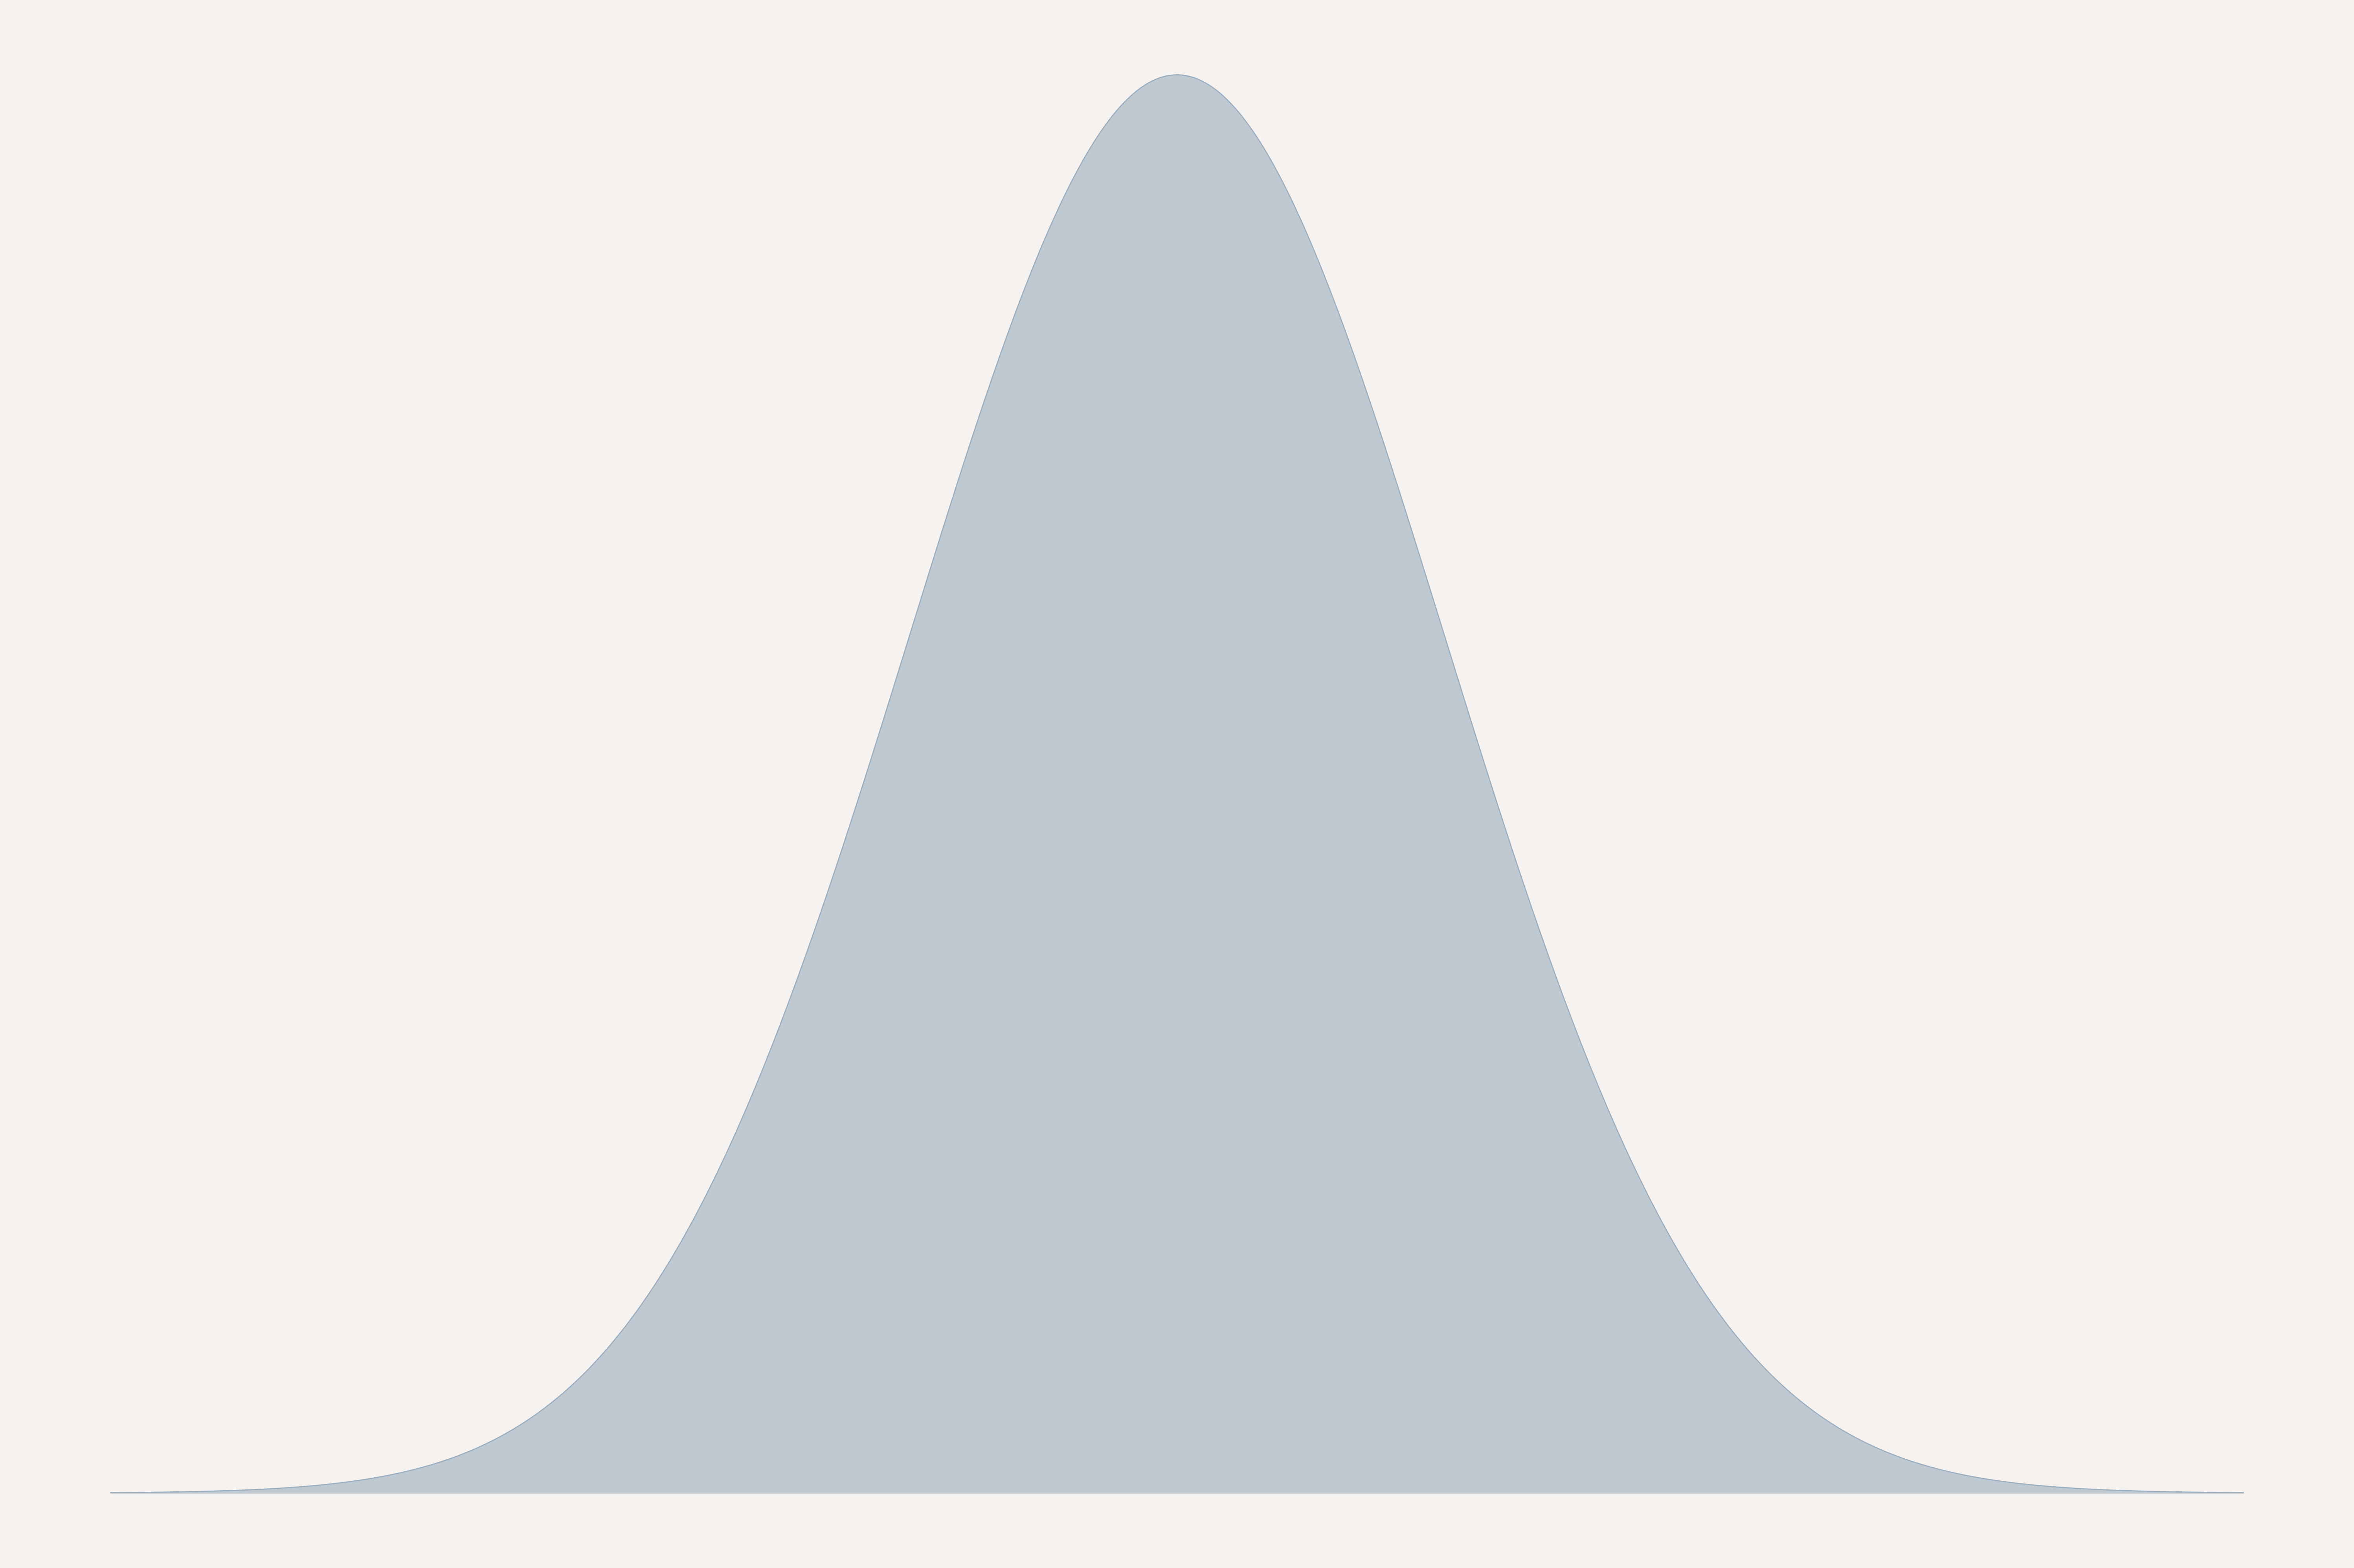

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# ===================== 自定义配置区（可直接修改）=====================
mu = 0               # 正态分布均值
sigma = 1            # 正态分布标准差
color_main = "#9CAFC0"# 莫兰迪主色（曲线+填充色，默认浅咖色）
color_bg = "#F5F2EF" # 图片背景色（莫兰迪浅米色，贴合主色）
fig_size = (60, 40)    # 图片尺寸(宽, 高)
fill_alpha = 0.6     # 填充区域透明度（0-1）
line_width = 2       # 分布曲线宽度
# =====================================================================

# 设置绘图风格，隐藏默认边框和网格
sns.set_style("white")
plt.rcParams['figure.facecolor'] = color_bg  # 设置图片背景色

# 生成正态分布数据
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)  # 取4个标准差范围，覆盖绝大部分分布
y = norm.pdf(x, loc=mu, scale=sigma)                # 计算正态分布概率密度

# 创建画布
fig, ax = plt.subplots(figsize=fig_size)

# 绘制正态分布：曲线+填充面积
ax.plot(x, y, color=color_main, linewidth=line_width)
ax.fill_between(x, y, color=color_main, alpha=fill_alpha)

# ===================== 核心：隐藏所有文字和视觉元素 =====================
ax.set_xticks([])          # 隐藏x轴刻度
ax.set_yticks([])          # 隐藏y轴刻度
ax.set_xlabel("")          # 清空x轴标签
ax.set_ylabel("")          # 清空y轴标签
ax.set_title("")           # 清空标题
ax.spines['top'].set_visible(False)    # 隐藏上边框
ax.spines['right'].set_visible(False)  # 隐藏右边框
ax.spines['left'].set_visible(False)   # 隐藏左边框
ax.spines['bottom'].set_visible(False)# 隐藏下边框
ax.set_facecolor(color_bg)# 子图背景色与整体一致
plt.tight_layout()         # 紧凑布局，避免留白

# 显示/保存图片（如需保存，取消下方plt.savefig注释，可修改路径和dpi）
plt.show()
# plt.savefig("normal_dist_morandi.png", dpi=300, bbox_inches='tight', pad_inches=0)

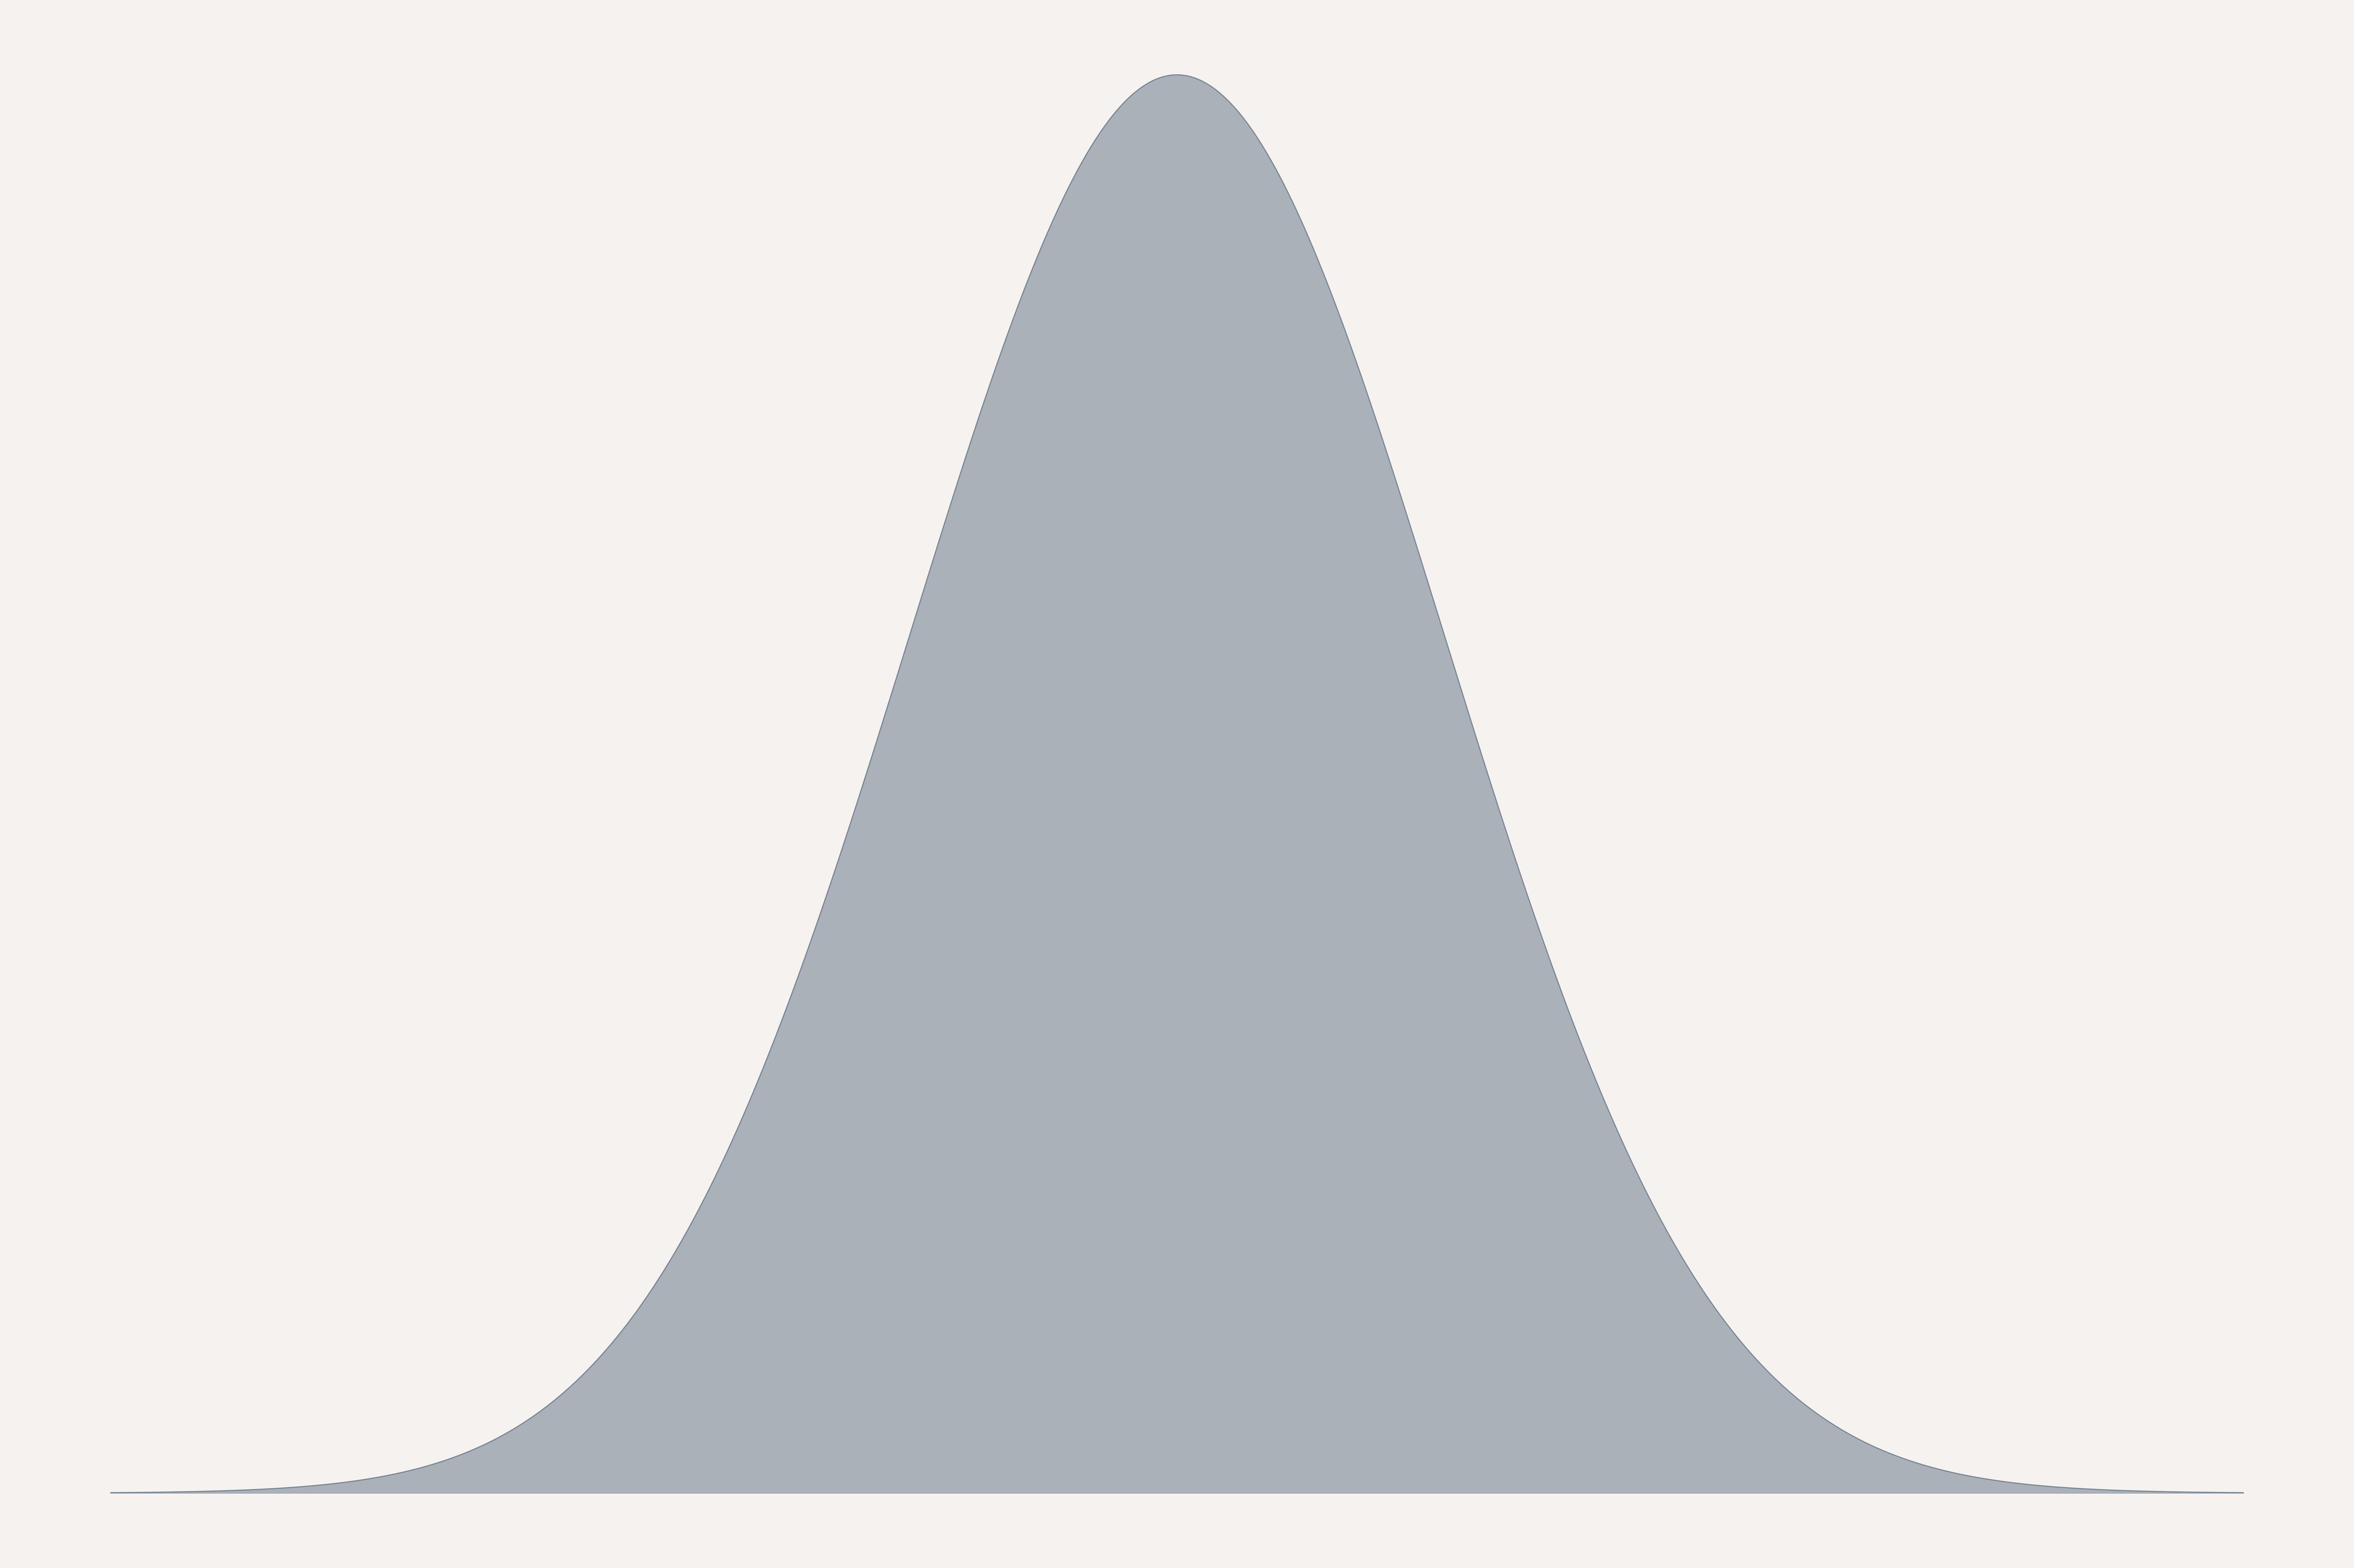

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# ===================== 自定义配置区（可直接修改）=====================
mu = 30               # 正态分布均值
sigma = 20            # 正态分布标准差
color_main = "#788694"# 莫兰迪主色（曲线+填充色，默认浅咖色）
color_bg = "#F5F2EF" # 图片背景色（莫兰迪浅米色，贴合主色）
fig_size = (60, 40)    # 图片尺寸(宽, 高)
fill_alpha = 0.6     # 填充区域透明度（0-1）
line_width = 2       # 分布曲线宽度
# =====================================================================

# 设置绘图风格，隐藏默认边框和网格
sns.set_style("white")
plt.rcParams['figure.facecolor'] = color_bg  # 设置图片背景色

# 生成正态分布数据
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)  # 取4个标准差范围，覆盖绝大部分分布
y = norm.pdf(x, loc=mu, scale=sigma)                # 计算正态分布概率密度

# 创建画布
fig, ax = plt.subplots(figsize=fig_size)

# 绘制正态分布：曲线+填充面积
ax.plot(x, y, color=color_main, linewidth=line_width)
ax.fill_between(x, y, color=color_main, alpha=fill_alpha)

# ===================== 核心：隐藏所有文字和视觉元素 =====================
ax.set_xticks([])          # 隐藏x轴刻度
ax.set_yticks([])          # 隐藏y轴刻度
ax.set_xlabel("")          # 清空x轴标签
ax.set_ylabel("")          # 清空y轴标签
ax.set_title("")           # 清空标题
ax.spines['top'].set_visible(False)    # 隐藏上边框
ax.spines['right'].set_visible(False)  # 隐藏右边框
ax.spines['left'].set_visible(False)   # 隐藏左边框
ax.spines['bottom'].set_visible(False)# 隐藏下边框
ax.set_facecolor(color_bg)# 子图背景色与整体一致
plt.tight_layout()         # 紧凑布局，避免留白

# 显示/保存图片（如需保存，取消下方plt.savefig注释，可修改路径和dpi）
plt.show()
# plt.savefig("normal_dist_morandi.png", dpi=300, bbox_inches='tight', pad_inches=0)